In [1]:
import numpy as np
from matplotlib import pyplot as plt

from pyloki.config import ParamLimits, PulsarSearchConfig
from pyloki.detection import thresholding
from pyloki.ffa import DynamicProgramming
from pyloki.periodogram import PruningStatsPlotter, ScatteredPeriodogram
from pyloki.prune import prune_dyp_tree
from pyloki.simulation.pulse import PulseSignalConfig

tobs = 2147.483648


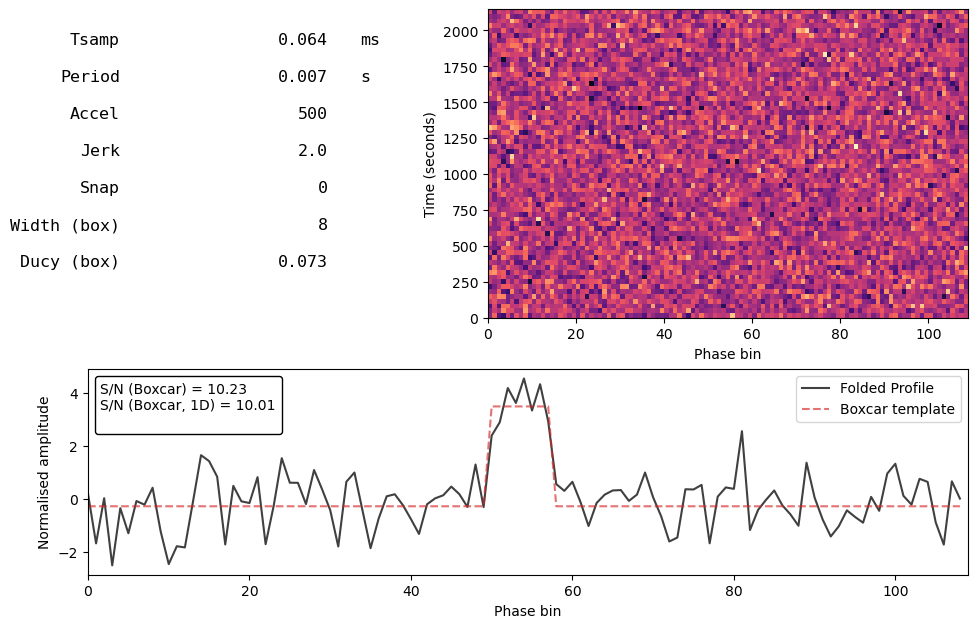

In [2]:
pulsar_period = 0.007
dt = 64e-6
accel = 500
jerk = 2.0
nsamps = 2**25
mod_kwargs = {"acc": accel, "jerk": jerk}
cfg = PulseSignalConfig(
    period=pulsar_period,
    dt=dt,
    nsamps=nsamps,
    snr=10.0,
    ducy=0.1,
    mod_kwargs=mod_kwargs,
)
print(f"tobs = {cfg.tobs}")
tim_data = cfg.generate(shape="gaussian")
tim_data.plot_fold(cfg.freq, cfg.fold_bins, mod_kwargs=mod_kwargs)
plt.show()

In [3]:
eta = 1
nbins = 64
p = ParamLimits.from_upper([jerk, accel, cfg.freq], (-2.0 * jerk, jerk * 2.0), cfg.tobs)
print(f"Param limits: {p.limits}")
bseg_brute = cfg.nsamps // 8192
bseg_ffa = cfg.nsamps // 128

search_cfg = PulsarSearchConfig(
    nsamps=cfg.nsamps,
    tsamp=cfg.dt,
    nbins=nbins,
    eta=eta,
    param_limits=p.limits,
    bseg_brute=bseg_brute,
    bseg_ffa=bseg_ffa,
    prune_poly_order=3,
    ducy_max=0.2,
    wtsp=1.5,
    use_fourier=True,
    use_conservative_tile=False,
    branch_max=32,
)
dyp = DynamicProgramming(tim_data, search_cfg)
dyp.initialize()
dyp.execute()

Param limits: [[-4.00000000e+00  4.00000000e+00]
 [-3.79496730e+03  4.79496730e+03]
 [ 1.41502532e+02  1.44211753e+02]]


2026-02-24 13:13:40 INFO     - pyloki.ffa - FFA initialize: Grid sizes: [3.46195593e+08 7.56275812e+06             
                             1.19209290e-01]

2026-02-24 13:13:41 INFO     - pyloki.ffa - ffa level:  0, leaves: 4.46, fold dims: (8192, 1, 1, 22, 2, 33)

                    INFO     - pyloki.ffa - ffa_initialize finished, Elapsed time: 0.419 seconds

Output()

...

                    INFO     - pyloki.ffa - ffa level:  4, leaves:  8.50, fold dims: (512, 1, 1, 363, 2, 33)

                    INFO     - pyloki.ffa - ffa level:  5, leaves:  9.51, fold dims: (256, 1, 1, 727, 2, 33)

                    INFO     - pyloki.ffa - ffa level:  6, leaves: 12.51, fold dims: (128, 1, 4, 1454, 2, 33)

                    INFO     - pyloki.ffa - FFA complete: Grid sizes: [1.32063138e+03 1.84637650e+03               
                             1.86264515e-03]

                    INFO     - pyloki.ffa - ffa_execute finished, Elapsed time: 3.480 seconds

In [4]:
branching_pattern = search_cfg.generate_branching_pattern(kind="taylor", ref_seg=0)
branching_pattern

array([8.        , 3.        , 2.        , 3.        , 1.        ,
       3.        , 2.        , 3.        , 2.01375516, 1.4897541 ,
       1.        , 1.        , 1.        , 9.        , 2.        ,
       1.        , 1.        , 1.        , 1.        , 3.        ,
       1.        , 1.        , 1.        , 1.        , 3.        ,
       1.        , 1.        , 1.        , 2.01375516, 1.4897541 ,
       2.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 3.        , 3.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 3.        , 2.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

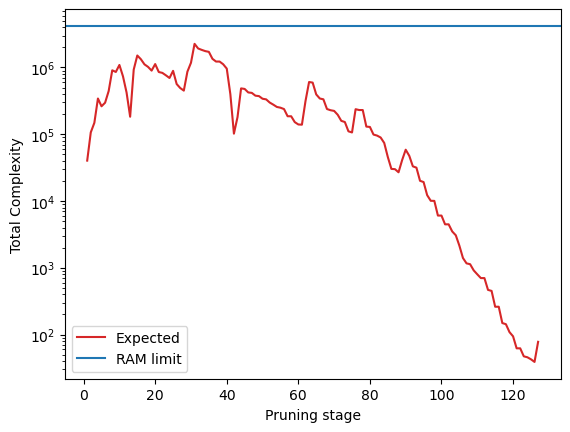

In [5]:
thresholds = np.array([2.2, 2.2, 2.5, 2.5, 2.6, 3.1, 3. , 3.1, 3.4, 3.2, 3.4, 3.6, 3.9,
       4. , 3.9, 3.8, 3.8, 3.7, 3.7, 4.2, 4.2, 3.9, 3.9, 3.9, 4.4, 4.5,
       4.4, 4.3, 4.2, 4.2, 4.1, 4.2, 4.1, 4. , 3.9, 4.2, 4.2, 3.8, 4.1,
       4.2, 4.7, 5.1, 5.2, 5.1, 4.9, 5. , 4.8, 4.9, 4.7, 4.8, 4.7, 4.8,
       4.8, 4.8, 4.7, 4.7, 4.9, 4.6, 4.9, 4.9, 4.7, 5. , 4.9, 4.8, 5.1,
       5.1, 5. , 5.2, 5.1, 5. , 5.1, 5.2, 5.1, 5.3, 5.2, 5.3, 5.3, 5. ,
       5.5, 5.3, 5.5, 5.4, 5.4, 5.5, 5.7, 5.8, 5.6, 5.7, 5.8, 5.7, 5.8,
       5.9, 5.8, 6. , 5.9, 6.1, 6.1, 5.9, 6.2, 5.9, 6.2, 5.8, 6.2, 6.2,
       6.3, 6.4, 6.4, 6.3, 6.4, 6.4, 6.4, 6. , 6.5, 6.4, 6.6, 6.3, 6.7,
       6.6, 6.7, 6.7, 6.8, 6.4, 6.8, 6.7, 6.7, 6.7, 6.3])
thresh_state = thresholding.evaluate_scheme(
    thresholds,
    branching_pattern,
    ref_ducy=0.1,
    nbins=64,
    ntrials=1024,
    snr_final=10.0,
    ducy_max=0.2,
    wtsp=1.5,
)
x = np.arange(1, len(branching_pattern) + 1)
plt.semilogy(
    x,
    np.array(thresh_state.get_info("complexity")) * dyp.nparam_vol,
    label="Expected",
    c="tab:red",
)
plt.axhline(2**22, label="RAM limit", c="tab:blue")
plt.xlabel("Pruning stage")
plt.ylabel("Total Complexity")
plt.legend()
plt.show()

In [6]:
result_file = prune_dyp_tree(
    dyp,
    thresholds,
    n_runs=16,
    max_sugg=2**22,
    outdir="pruning_results/jerk_test/",
    file_prefix="test_jerk",
    poly_basis="taylor",
    n_workers=4,
)

2026-02-24 13:16:15 INFO     - pyloki.prune - Starting Pruning for 16 runs, with 4 workers

Output()

2026-02-24 13:21:40 INFO     - pyloki.prune - Pruning complete. Results saved to                                   
                             pruning_results/jerk_test/test_jerk_pruning_nstages_128_results.h5

In [7]:
pgram = ScatteredPeriodogram.load(result_file)
print(f"True params, j: {cfg.mod_kwargs["jerk"]:.3f}, a: {cfg.mod_kwargs["acc"]:.3f}, f: {cfg.freq:.10f}")
print(pgram.get_summary_cands(10, run_id=None))

True params, j: 2.000, a: 500.000, f: 142.8571428571
Top candidates:
dparams: djerk: 0.00121475483, daccel: 0.2102713894, dfreq: 1.455191523e-05
Run: 016_03, S/N: 9.52, jerk: 2.0006, accel: 499.69, freq: 142.857171
Run: 016_03, S/N: 9.41, jerk: 2.0006, accel: 499.69, freq: 142.857157
Run: 016_03, S/N: 9.15, jerk: 1.9993, accel: 499.93, freq: 142.857115
Run: 016_03, S/N: 9.15, jerk: 1.9993, accel: 499.93, freq: 142.857086
Run: 016_03, S/N: 9.11, jerk: 1.9993, accel: 499.93, freq: 142.857100
Run: 016_03, S/N: 9.02, jerk: 1.9993, accel: 499.93, freq: 142.857071
Run: 016_03, S/N: 8.98, jerk: 1.9981, accel: 499.97, freq: 142.857057
Run: 016_03, S/N: 8.95, jerk: 1.9981, accel: 499.97, freq: 142.857042
Run: 033_05, S/N: 8.88, jerk: 1.9997, accel: 499.95, freq: 142.857125
Run: 016_03, S/N: 8.86, jerk: 1.9981, accel: 499.97, freq: 142.857013


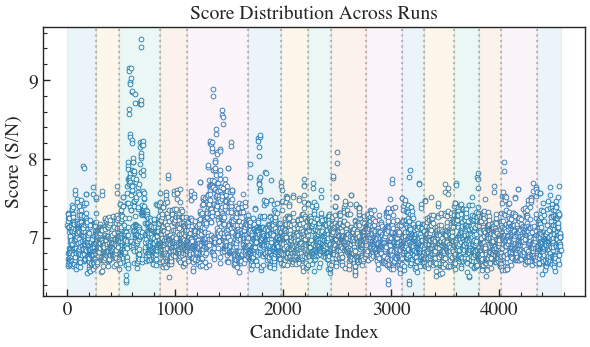

In [8]:
pgram.plot_scores(kind="scatter", run_id=None)
plt.show()

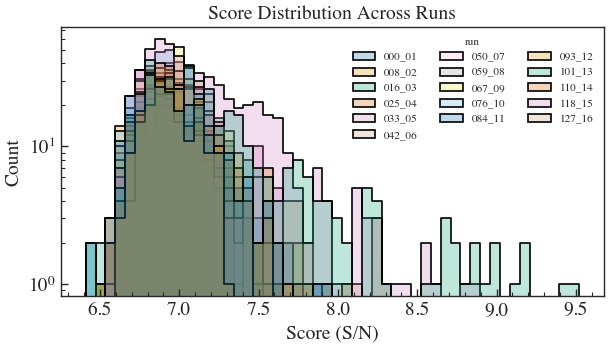

In [9]:
pgram.plot_scores(kind="hist", run_id=None)
plt.show()

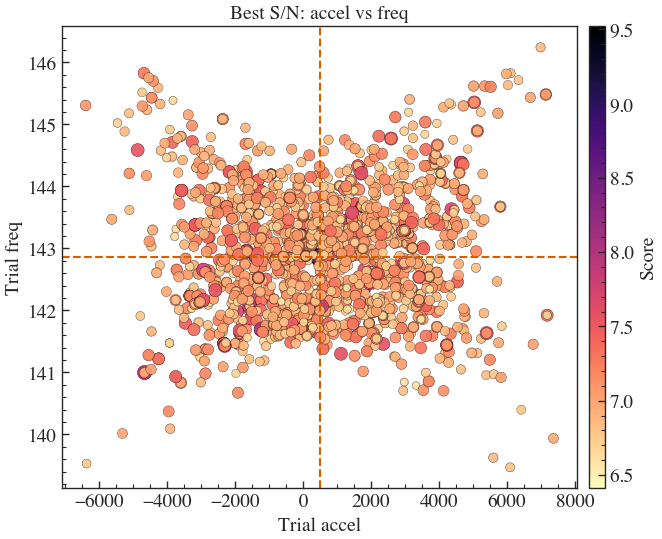

In [10]:
pgram.plot_correlation("accel", "freq", true_values={"accel": cfg.mod_kwargs["acc"], "freq": cfg.freq}, run_id=None)
plt.show()

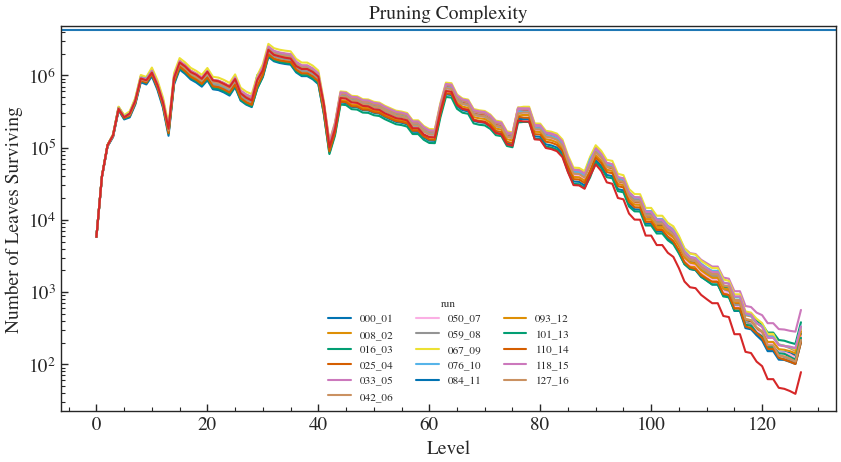

In [11]:
pstats = PruningStatsPlotter.load(result_file)
fig = pstats.plot_level_stats(run_id=None)
x = np.arange(0, len(branching_pattern) + 1)
ax_list = fig.axes
ax_list[0].plot(x, np.concatenate(([1], thresh_state.get_info("complexity"))) * dyp.nparam_vol, label="Expected", c="tab:red")
ax_list[0].axhline(2**22, label="RAM limit", c="tab:blue")
plt.show()